# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
##% title Imports
import os
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV, RidgeCV, LassoCV, Lasso
from scipy import stats

from popy.io_tools import *
from popy.behavior_data_tools import *
from popy.neural_data_tools import time_normalize_session, scale_neural_data, remove_low_fr_neurons, remove_trunctuated_neurons
from popy.decoding.decoder_tools import *
from popy.plotting.plotting_tools import *
#from popy.plotting.plot_behavior import show_target_selection 
import popy.config as cfg
from popy.plotting.plot_cortical_grid import plot_on_cortical_grid

# @title Helper Functions
from run_neural_value_across_target import NEW_project_across_targets
from helpers import load_data_custom

PATH = cfg.PROJECT_PATH_LOCAL


/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-91jycrxk because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


---
# Get data

In [2]:
monkey, session, subregion = 'ka', '210322', 'MCC'

time_of_interest = [-4, -2]  # seconds
build_data = False

all_figs = []
#neural_dataset = load_mega_custom(monkey='ka', subregion='MCC')
floc = 'temp/{}_{}_neural.nc'.format(monkey, session)

if not build_data: 
    neural_dataset_all = xr.open_dataset(floc)
else:
    neural_dataset_all = load_data_custom(monkey, session, n_extra_trials=(-1, 1), sr=10)
    # save the dataset
    neural_dataset_all.to_netcdf(floc)

neural_dataset = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 16, trial_id: 386, time: 225)
Coordinates: (12/25)
  * unit              (unit) object 'MCC_06_01' 'MCC_07_01' ... 'MCC_16_01'
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object ...
    session           (unit) object ...
    area              (unit) object ...
    ...                ...
    R_3               (trial_id) float64 ...
    R_4               (trial_id) float64 ...
    R_5               (trial_id) float64 ...
    R_6               (trial_id) float64 ...
    R_7               (trial_id) float64 ...
    R_8               (trial_id) float64 ...
Data variables:
    firing_rates      (trial_id, unit, time) float64 ...
Attributes:
    bin_size:  0.1

---
# Section 1: Projection to value subspace

## Define the value subspace

In [3]:
neural_dataset = neural_dataset.sel(time=slice(*time_of_interest))

neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 16, trial_id: 386, time: 21)
Coordinates: (12/25)
  * unit              (unit) object 'MCC_06_01' 'MCC_07_01' ... 'MCC_16_01'
    unit_id_original  (unit) int64 ...
    channel           (unit) int64 ...
    monkey            (unit) object ...
    session           (unit) object ...
    area              (unit) object ...
    ...                ...
    R_3               (trial_id) float64 ...
    R_4               (trial_id) float64 ...
    R_5               (trial_id) float64 ...
    R_6               (trial_id) float64 ...
    R_7               (trial_id) float64 ...
    R_8               (trial_id) float64 ...
Data variables:
    firing_rates      (trial_id, unit, time) float64 ...
Attributes:
    bin_size:  0.1

In [ ]:
# project the neural data across targets - from high dimensional space to 3 dimensional space
data_projected = data_projected = NEW_project_across_targets(neural_dataset)
data_projected


In [ ]:
# Extract 'neural values' for the specified time range by averaging across time points
neural_values = data_projected.sel(time=slice(*time_of_interest)).mean(dim='time')
neural_values

<xarray.DataArray (subspace: 3, trial_id: 386)>
array([[-0.52278723, -0.19168411,  1.12070999, ..., -0.86070589,
         1.03537921, -1.16832318],
       [-0.64484057, -0.06868332,  0.97465193, ..., -0.70025516,
         1.06374736, -0.99958317],
       [-0.40951978, -0.0212291 ,  1.10404777, ..., -0.67360305,
         1.05880359, -1.09506975]])
Coordinates: (12/17)
  * subspace     (subspace) <U8 'target_1' 'target_2' 'target_3'
  * trial_id     (trial_id) int64 8 9 10 11 12 13 14 ... 415 416 417 418 419 423
    block_id     (trial_id) int64 ...
    best_target  (trial_id) int64 ...
    target       (trial_id) float64 3.0 1.0 1.0 1.0 1.0 ... 3.0 3.0 3.0 3.0 3.0
    feedback     (trial_id) float64 ...
    ...           ...
    R_3          (trial_id) float64 ...
    R_4          (trial_id) float64 ...
    R_5          (trial_id) float64 ...
    R_6          (trial_id) float64 ...
    R_7          (trial_id) float64 ...
    R_8          (trial_id) float64 ...

In [ ]:
# Extract neural values and their change
from run_neural_value_across_target import extract_neural_data

results_df = extract_neural_data(neural_values, data_projected)
results_df

,trial_id,target,feedback,type,V_neural,V_neural_p1,dV_neural,V_behav,V_behav_p1,dV_behav
0,9,1.0,1,within,-0.191684,1.120710,1.312394,0.06166137168784155,0.5016302333407429,-0.439969
1,9,1.0,1,alter,-0.068683,0.974652,1.043335,0.06166137168784155,0.5016302333407429,-0.439969
2,9,1.0,1,alter,-0.021229,1.104048,1.125277,0.06166137168784155,0.5016302333407429,-0.439969
3,10,1.0,1,within,1.120710,1.258601,0.137892,0.5016302333407429,0.7208974122600382,-0.219267
4,10,1.0,1,alter,0.974652,1.015392,0.040740,0.5016302333407429,0.7208974122600382,-0.219267
...,...,...,...,...,...,...,...,...,...,...
1000,417,3.0,0,alter,1.016980,-0.700255,-1.717235,0.8026880667677521,0.4495303117695762,0.353158
1001,417,3.0,0,within,1.319715,-0.673603,-1.993318,0.8026880667677521,0.4495303117695762,0.353158
1002,418,3.0,1,alter,-0.860706,1.035379,1.896085,0.4495303117695762,0.6917198338747432,-0.242190
1003,418,3.0,1,alter,-0.700255,1.063747,1.764003,0.4495303117695762,0.6917198338747432,-0.242190


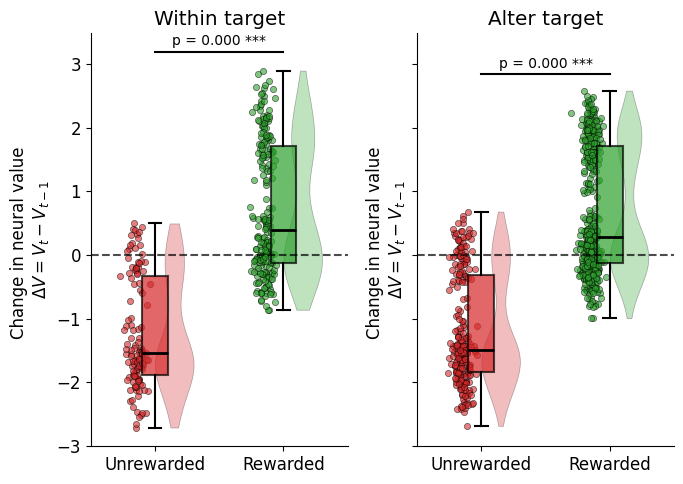

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline


# fontsize = 8
plt.rcParams.update({'font.size': 12})

# Create the figure
fig, axs = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

def create_r_style_plot(ax, data, x_col, y_col, palette, title):
    """Create R-style plot with violin, box, and jittered points"""
    
    # Get unique categories
    # sort by x_col
    data = data.copy().sort_values(by=x_col)
    categories = data[x_col].unique()
    x_positions = np.arange(len(categories))
    
    # Create violin plots (distributions) - slightly offset to the right
    violin_parts = ax.violinplot([data.loc[data[x_col] == cat, y_col].values for cat in categories], 
                                positions=x_positions + 0.15, widths=0.3, showmeans=False, 
                                showmedians=False, showextrema=False)
    
    # Color the violin plots
    colors = [palette[str(cat)] for cat in categories]
    for pc, color in zip(violin_parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.3)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)
    
    # Create boxplots - centered
    box_data = [data.loc[data[x_col] == cat, y_col].values for cat in categories]
    bp = ax.boxplot(box_data, positions=x_positions, widths=0.2, patch_artist=True,
                   boxprops=dict(alpha=0.7, linewidth=1.5),
                   showfliers=False,
                   medianprops=dict(color='black', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='black', markersize=3, alpha=0.5))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Add jittered points - slightly offset to the left
    for i, cat in enumerate(categories):
        y_data = data.loc[data[x_col] == cat, y_col].values
        x_jitter = np.random.normal(x_positions[i] - 0.15, 0.04, size=len(y_data))
        ax.scatter(x_jitter, y_data, alpha=0.6, s=20, 
                  color=colors[i], edgecolor='black', linewidth=0.5)
    
    # Perform t-test and add significance
    if len(categories) == 2:
        group1_data = data.loc[data[x_col] == categories[0], y_col]
        group2_data = data.loc[data[x_col] == categories[1], y_col]
        #_, p_value = stats.ttest_ind(group1_data, group2_data)
        U1, p_value = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

        
        # Position for significance bar
        y_max = data[y_col].max()
        y_pos = y_max + 0.1 * abs(y_max)
        
        # Add significance annotation
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'
        
        # Add the bar and text for p-value
        ax.plot([0, 1], [y_pos, y_pos], '-k', lw=1.5)
        ax.text(0.5, y_pos + 0.02 * abs(y_max), f'p = {p_value:.3f} {significance}', 
                ha='center', va='bottom', fontsize=10)
    
    # Formatting
    ax.axhline(0, linestyle='--', alpha=0.7, color='black')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Unrewarded', 'Rewarded'])
    ax.set_ylabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$')
    ax.set_xlabel('')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return ax

# Create the plots
palette = {'0': 'tab:red', '1': 'tab:green'}

# Within target plot
create_r_style_plot(axs[0], 
                   results_df.loc[results_df['type'] == 'within'], 
                   'feedback', 'dV_neural', palette, 'Within target')

# Alter target plot
create_r_style_plot(axs[1], 
                   results_df.loc[results_df['type'] == 'alter'], 
                   'feedback', 'dV_neural', palette, 'Alter target')

plt.tight_layout()
plt.show()


# save svg
#plt.savefig('figs/dV_neural_behav_rstyle.svg', format='svg', bbox_inches='tight')